In [1]:
import numpy as np
import matplotlib.pyplot as plt

import sys
import os
import copy

sys.path.append(os.path.abspath("..")) 

from halo_model.power_spectra.matter_power import MatterPower
from halo_model.power_spectra.angular_power import AngularPower
from halo_model.halos.base.profile.profile import CompositeProfile

from halo_model.config.config import Config

In [ ]:
#import ingredient models

from halo_model.halos.base.clump_mass_func.models.giocoli2010_mod import ClumpMassFuncGiocoli2010_mod
from halo_model.halos.base.clump_mass_func.models.giocoli2010 import ClumpMassGiocoli2010

from halo_model.halos.base.concentration.models.neto2007 import ConcentrationNeto2007
from halo_model.halos.base.concentration.models.pieri2009_clumps import ConcentrationPieri2009_clumps

from halo_model.halos.base.mass_func.models.sheth1999 import MassFuncSheth1999

from halo_model.halos.base.profile.models.nfw import ProfileNFW
from halo_model.halos.base.profile.models.stellarpowerlaw import ProfileStellarPowerLaw
from halo_model.halos.base.profile.models.pointmass import ProfilePointMass


from halo_model.halos.base.bias.models.tinker2010 import BiasTinker2010
from halo_model.halos.base.r_vir.models.SO import R_virSO
from halo_model.halos.base.shmr.models.moster2013 import SMHRMoster2013


In [ ]:
cfg = Config()

mass_func = MassFuncSheth1999()

smooth_profile = ProfileNFW(ConcentrationNeto2007(cfg), R_virSO(cfg))

bias = BiasTinker2010(cfg)

clump_profile = ProfileNFW(ConcentrationPieri2009_clumps(ConcentrationNeto2007(cfg), d_vir=0.3), 
                           R_virSO(cfg))

clump_distribution = ProfileNFW(ConcentrationNeto2007(cfg), R_virSO(cfg))
clump_mass_func = ClumpMassGiocoli2010(cfg)

In [ ]:
smhr = SMHRMoster2013()
stellar_profile = ProfilePointMass() #ProfileStellarPowerLaw(smhr)


def w_star(cosmo, M, z):
    return smhr(cosmo, M, z)
def w_smooth(cosmo, M, z):
    return 1 - w_star(cosmo, M, z)

smooth_profile = CompositeProfile(
    smooth_profile, stellar_profile,
    weights=[w_smooth, w_star]
)
clump_profile = CompositeProfile(
    clump_profile, stellar_profile,
    weights=[w_smooth, w_star]
)

In [4]:
l_vals = np.logspace(np.log10(cfg.l_min), np.log10(cfg.l_max), cfg.N_l)

Cl = AngularPower(cfg, 
                mass_func=mass_func, 
                smooth_profile=smooth_profile, 
                bias=bias,
                clump_mass_func=clump_mass_func, 
                clump_profile=clump_profile, 
                clump_distribution=clump_distribution)

l_vals = np.logspace(np.log10(cfg.l_min), np.log10(cfg.l_max), cfg.N_l)
dict_std = {}

dict_std['Cl_1h_ss'] = np.array([Cl.C_1h_ss(l) for l in l_vals])
dict_std['Cl_1h_sc'] = np.array([Cl.C_1h_sc(l) for l in l_vals])
dict_std['Cl_1h_self_c'] = np.array([Cl.C_1h_self_c(l) for l in l_vals])
dict_std['Cl_1h_cc'] = np.array([Cl.C_1h_cc(l) for l in l_vals])
dict_std['Cl_2h'] = np.array([Cl.C_2h(l) for l in l_vals])
dict_std['Cl_tot'] = dict_std['Cl_2h'] +dict_std['Cl_1h_ss'] + dict_std['Cl_1h_sc'] + dict_std['Cl_1h_self_c'] + dict_std['Cl_1h_cc']


interpolating f_sub function...
interpolating Ic and Jc functions...
interpolating f_sub function...
interpolating Ic and Jc functions...
interpolating f_sub function...
interpolating Ic and Jc functions...
interpolating f_sub function...
interpolating Ic and Jc functions...
interpolating f_sub function...
interpolating Ic and Jc functions...
interpolating f_sub function...
interpolating Ic and Jc functions...
interpolating power spectra over k and z


In [5]:
Cl_betas = []
Cl_beta_dicts = []

for beta in [-0.1, -0.3, -0.5, -1]:
    cfg_local = copy.deepcopy(cfg)
    cfg_local.m0 = 2e9
    cfg_local.beta = beta

    clump_mass_func = ClumpMassFuncGiocoli2010_mod(cfg_local.m0, cfg_local.beta)
    
    Cl = AngularPower(cfg_local, 
                    mass_func=mass_func, 
                    smooth_profile=smooth_profile, 
                    bias=bias,
                    clump_mass_func=clump_mass_func, 
                    clump_profile=clump_profile, 
                    clump_distribution=clump_distribution)
    Cl_betas.append(Cl)
    
    temp_dict = {}

    temp_dict['Cl_1h_ss'] = np.array([Cl.C_1h_ss(l) for l in l_vals])
    temp_dict['Cl_1h_sc'] = np.array([Cl.C_1h_sc(l) for l in l_vals])
    temp_dict['Cl_1h_self_c'] = np.array([Cl.C_1h_self_c(l) for l in l_vals])
    temp_dict['Cl_1h_cc'] = np.array([Cl.C_1h_cc(l) for l in l_vals])
    temp_dict['Cl_2h'] = np.array([Cl.C_2h(l) for l in l_vals])
    temp_dict['Cl_tot'] = temp_dict['Cl_2h'] +temp_dict['Cl_1h_ss'] + temp_dict['Cl_1h_sc'] + temp_dict['Cl_1h_self_c'] + temp_dict['Cl_1h_cc']
    Cl_beta_dicts.append(temp_dict)


interpolating f_sub function...
interpolating Ic and Jc functions...
interpolating f_sub function...
interpolating Ic and Jc functions...
interpolating f_sub function...
interpolating Ic and Jc functions...
interpolating f_sub function...
interpolating Ic and Jc functions...
interpolating f_sub function...
interpolating Ic and Jc functions...
interpolating f_sub function...
interpolating Ic and Jc functions...
interpolating power spectra over k and z
interpolating f_sub function...
interpolating Ic and Jc functions...
interpolating f_sub function...
interpolating Ic and Jc functions...
interpolating f_sub function...
interpolating Ic and Jc functions...
interpolating f_sub function...
interpolating Ic and Jc functions...
interpolating f_sub function...
interpolating Ic and Jc functions...
interpolating f_sub function...
interpolating Ic and Jc functions...
interpolating power spectra over k and z
interpolating f_sub function...
interpolating Ic and Jc functions...
interpolating f_sub f

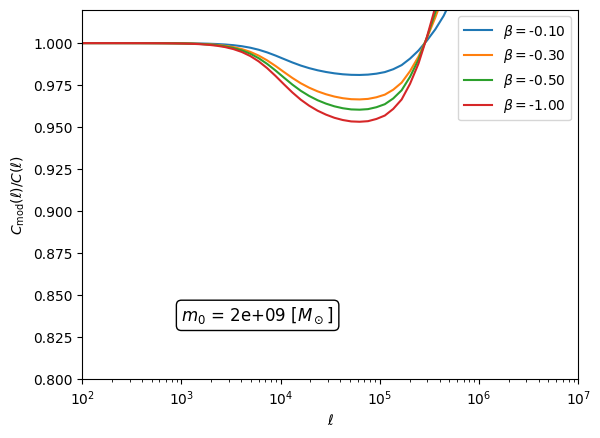

In [ ]:
for i, dict_ in enumerate(Cl_beta_dicts):

    plt.plot(l_vals, dict_['Cl_tot']/dict_std['Cl_tot'], label=r'$\beta =$' + f'{Cl_betas[i].cfg.beta:.2f}')
        
plt.xscale("log")
plt.ylim(0.8, 1.2)
plt.xlim(np.min(l_vals), np.max(l_vals))

plt.xlabel(r'$\ell$')
plt.ylabel(r'$C_{\mathrm{mod}}(\ell) / C(\ell)$')

plt.legend()

plt.text(
    0.2, 0.2,
    r"$m_0$" +  f" = {Cl_betas[i].cfg.m0:.0e} " + r"$[M_\odot]$",
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=1)
)
plt.savefig("plots_Cl_modified_cmf/Cl_mod_beta.pdf")
plt.show()

In [7]:
Cl_m0s = []
Cl_m0_dicts = []

for m0 in [1e7, 1e8, 1e9, 1e10]:
    cfg_local = copy.deepcopy(cfg)
    cfg_local.m0 = m0
    cfg_local.beta = -1

    clump_mass_func = ClumpMassFuncGiocoli2010_mod(cfg_local.m0, cfg_local.beta)
    
    Cl = AngularPower(cfg_local, 
                    mass_func=mass_func, 
                    smooth_profile=smooth_profile, 
                    bias=bias,
                    clump_mass_func=clump_mass_func, 
                    clump_profile=clump_profile, 
                    clump_distribution=clump_distribution)
    Cl_m0s.append(Cl)
    
    temp_dict = {}

    temp_dict['Cl_1h_ss'] = np.array([Cl.C_1h_ss(l) for l in l_vals])
    temp_dict['Cl_1h_sc'] = np.array([Cl.C_1h_sc(l) for l in l_vals])
    temp_dict['Cl_1h_self_c'] = np.array([Cl.C_1h_self_c(l) for l in l_vals])
    temp_dict['Cl_1h_cc'] = np.array([Cl.C_1h_cc(l) for l in l_vals])
    temp_dict['Cl_2h'] = np.array([Cl.C_2h(l) for l in l_vals])
    temp_dict['Cl_tot'] = temp_dict['Cl_2h'] +temp_dict['Cl_1h_ss'] + temp_dict['Cl_1h_sc'] + temp_dict['Cl_1h_self_c'] + temp_dict['Cl_1h_cc']
    Cl_m0_dicts.append(temp_dict)


interpolating f_sub function...
interpolating Ic and Jc functions...
interpolating f_sub function...
interpolating Ic and Jc functions...
interpolating f_sub function...
interpolating Ic and Jc functions...
interpolating f_sub function...
interpolating Ic and Jc functions...
interpolating f_sub function...
interpolating Ic and Jc functions...
interpolating f_sub function...
interpolating Ic and Jc functions...
interpolating power spectra over k and z
interpolating f_sub function...
interpolating Ic and Jc functions...
interpolating f_sub function...
interpolating Ic and Jc functions...
interpolating f_sub function...
interpolating Ic and Jc functions...
interpolating f_sub function...
interpolating Ic and Jc functions...
interpolating f_sub function...
interpolating Ic and Jc functions...
interpolating f_sub function...
interpolating Ic and Jc functions...
interpolating power spectra over k and z
interpolating f_sub function...
interpolating Ic and Jc functions...
interpolating f_sub f

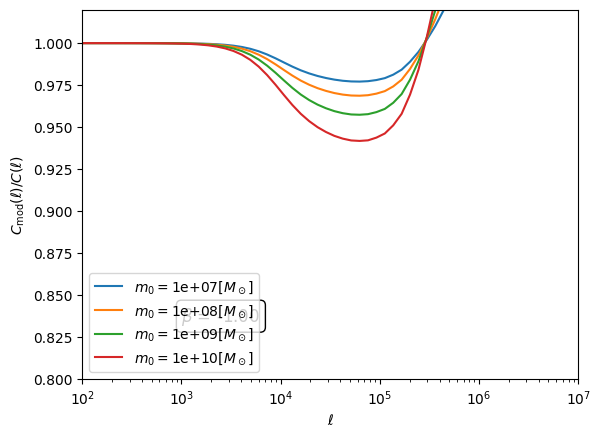

In [8]:
for i, dict_ in enumerate(Cl_m0_dicts):

    plt.plot(l_vals, dict_['Cl_tot']/dict_std['Cl_tot'], label=r'$m_0 =$' + f'{Cl_m0s[i].cfg.m0:.0e}'+ r"$[M_\odot]$")
        
plt.xscale("log")
plt.ylim(0.8, 1.02)
plt.xlim(np.min(l_vals), np.max(l_vals))

plt.xlabel(r'$\ell$')
plt.ylabel(r'$C_{\mathrm{mod}}(\ell) / C(\ell)$')

plt.legend()

plt.text(
    0.2, 0.2,
    r"$\beta$" +  f" = {Cl_m0s[i].cfg.beta:.2f}",
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=1)
)
plt.savefig("plots_Cl_modified_cmf/Cl_mod_m0.pdf")
plt.show()